In [1]:
import nbtest
import json
import numpy as np
random_seed = np.random.randint(10000)

In [2]:
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms
import shap

In [3]:
batch_size = 128
num_epochs = 2
device = torch.device('cpu')

class Net(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(nn.Conv2d(1, 10, kernel_size=5), nn.MaxPool2d(2), nn.ReLU(), nn.Conv2d(10, 20, kernel_size=5), nn.Dropout(), nn.MaxPool2d(2), nn.ReLU())
        self.fc_layers = nn.Sequential(nn.Linear(320, 50), nn.ReLU(), nn.Dropout(), nn.Linear(50, 10), nn.Softmax(dim=1))

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(-1, 320)
        x = self.fc_layers(x)
        return x

def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = (data.to(device), target.to(device))
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output.log(), target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100.0 * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

def test(model, device, test_loader):
    nbtest_tmpvar_0 = model.eval()
    nbtest.instrument(nbtest_tmpvar_0, 3, 44, 'PyTorch_Deep_Explainer_MNIST_example', 'nbtest_tmpvar_0', api='eval')
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = (data.to(device), target.to(device))
            output = model(data)
            test_loss += F.nll_loss(output.log(), target).item()
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100.0 * correct / len(test_loader.dataset):.0f}%)\n')
train_loader = torch.utils.data.DataLoader(datasets.MNIST('mnist_data', train=True, download=True, transform=transforms.Compose([transforms.ToTensor()])), batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(datasets.MNIST('mnist_data', train=False, transform=transforms.Compose([transforms.ToTensor()])), batch_size=batch_size, shuffle=True)
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
for epoch in range(1, num_epochs + 1):
    nbtest_tmpvar_1 = train(model, device, train_loader, optimizer, epoch)
    nbtest.instrument(nbtest_tmpvar_1, 3, 78, 'PyTorch_Deep_Explainer_MNIST_example', 'nbtest_tmpvar_1', api='train')
    test(model, device, test_loader)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.307050


Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.231691


Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.715361


Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.881470


Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.871651


...

Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.726792


Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.575655


Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.376018


Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.447450



Test set: Average loss: 0.0026, Accuracy: 9394/10000 (94%)



In [4]:
batch = next(iter(test_loader))
images, _ = batch
background = images[:100]
test_images = images[100:103]
e = shap.DeepExplainer(model, background)
shap_values = e.shap_values(test_images)

In [5]:
shap_numpy = list(np.transpose(shap_values, (4, 0, 2, 3, 1)))
test_numpy = np.swapaxes(np.swapaxes(test_images.numpy(), 1, -1), 1, 2)

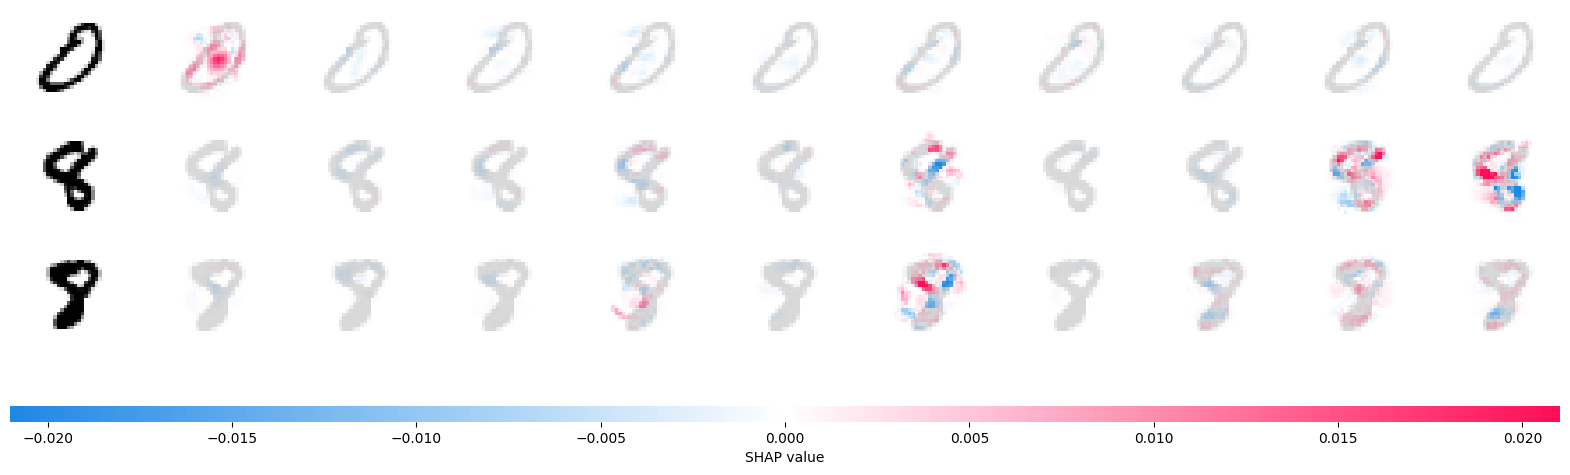

In [6]:
nbtest_tmpvar_2 = shap.image_plot(shap_numpy, -test_numpy)
nbtest.instrument(nbtest_tmpvar_2, 6, 1, 'PyTorch_Deep_Explainer_MNIST_example', 'nbtest_tmpvar_2', api='image_plot')